In [2]:
import pandas as pd
import numpy as np
import os


# step1 - data cleaning 

In [3]:
# ── STEP 1: Load the raw dataset ─────────────────────────────
# encoding="latin1" is needed because the file has some
# special characters that the default reader can't handle.
raw_path   = "startup_funding.csv"
clean_path = "startup_funding_clean.csv"

# Check if file exists first
if not os.path.exists(raw_path):
    print("\n⚠  File not found at:", raw_path)
    print("   Please download startup_funding.csv from Kaggle")
    print("   Link: https://www.kaggle.com/datasets/sudalairajkumar/indian-startup-funding")
    print("   Place it inside the  data/  folder")
    exit()

df = pd.read_csv(raw_path, encoding="latin1")

print(f"\n✓  Raw dataset loaded")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print(f"\n   Column names found:")
for c in df.columns:
    print(f"   → {c}")


✓  Raw dataset loaded
   Rows    : 3044
   Columns : 10

   Column names found:
   → ï»¿Sr No
   → Date dd/mm/yyyy
   → Startup Name
   → Industry Vertical
   → SubVertical
   → City  Location
   → Investors Name
   → InvestmentnType
   → Amount in USD
   → Remarks


In [4]:
df

,ï»¿Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJUâS,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN
...,...,...,...,...,...,...,...,...,...,...
3039,3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000",NaN
3040,3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund
3041,3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",NaN
3042,3043,30/01/2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN,"Strategic Funding, Minority stake"


In [5]:
df.columns = [
    "sr",           # serial number (we'll drop this)
    "date",         # date of funding
    "startup",      # startup name
    "industry",     # sector / industry vertical
    "subvertical",  # sub-category (we won't use this much)
    "city",         # city where startup is based
    "investors",    # investor name(s)
    "invest_type",  # funding stage: Seed, Series A, Series B etc.
    "amount_usd",   # funding amount in USD
    "remarks"       # extra notes (mostly empty)
]

In [6]:
df

,sr,date,startup,industry,subvertical,city,investors,invest_type,amount_usd,remarks
0,1,09/01/2020,BYJUâS,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN
...,...,...,...,...,...,...,...,...,...,...
3039,3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000",NaN
3040,3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund
3041,3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",NaN
3042,3043,30/01/2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN,"Strategic Funding, Minority stake"


In [7]:
# ── STEP 3: Clean the amount column ─────────────────────────
# The amount column is very messy. It has:
# - Commas inside numbers  →  1,000,000
# We need to turn this into a proper number column.

# Convert to string first so we can use text operations
df["amount_usd"] = df["amount_usd"].astype(str)

# Remove commas  →  "1,000,000"  becomes  "1000000"
df["amount_usd"] = df["amount_usd"].str.replace(",", "", regex=False)

# Remove extra spaces around values
df["amount_usd"] = df["amount_usd"].str.strip()

# Replace all "unknown" text values with NaN (blank / missing)
unknown_values = [
    "undisclosed", "Undisclosed", "UNDISCLOSED",
    "N/A", "n/a", "-", "nan", "", "none", "None", "unknown"]

df["amount_usd"] = df["amount_usd"].replace(unknown_values, np.nan)

# Now convert to a real number — any remaining text becomes NaN
df["amount_usd"] = pd.to_numeric(df["amount_usd"], errors="coerce")

filled = df["amount_usd"].notna().sum()
total= len(df)

In [8]:
total

3044

In [9]:
filled-total

np.int64(-979)

In [10]:
# ── STEP 4: Clean and parse the date column ──────────────────
# Dates come in different formats across years. We force-parse
# them and extract year + month as separate columns.

df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month

bad_dates = df["date"].isna().sum()

# Drop rows where we couldn't parse the date at all
# (these rows are usually completely empty or corrupted)
df = df.dropna(subset=["date"])

In [11]:
df

,sr,date,startup,industry,subvertical,city,investors,invest_type,amount_usd,remarks,year,month
0,1,2020-01-09,BYJUâS,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0,NaN,2020.0,1.0
1,2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,8048394.0,NaN,2020.0,1.0
2,3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0,NaN,2020.0,1.0
3,4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3000000.0,NaN,2020.0,1.0
4,5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1800000.0,NaN,2020.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3039,3040,2015-01-29,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,4500000.0,NaN,2015.0,1.0
3040,3041,2015-01-29,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,825000.0,Govt backed VC Fund,2015.0,1.0
3041,3042,2015-01-30,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,1500000.0,NaN,2015.0,1.0
3042,3043,2015-01-30,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN,"Strategic Funding, Minority stake",2015.0,1.0


In [12]:
len(df)

3036

In [13]:
# ── STEP 5: Clean city names ─────────────────────────────────
# The same city appears with many different spellings.
# Example: "Bangalore", "Bengalore", "bangalore" are all Bengaluru.
# We standardise them.

df["city"] = df["city"].astype(str).str.strip().str.title()

city_fixes = {
    "Bangalore"       : "Bengaluru",
    "Bengalore"       : "Bengaluru",
    "Banglore"        : "Bengaluru",
    "Bangalore "      : "Bengaluru",
    "New Delhi"       : "Delhi",
    "New Delhi "      : "Delhi",
    "Mumbai City"     : "Mumbai",
    "Gurgaon"         : "Gurugram",
    "Noida"           : "Delhi-NCR",
    "Nan"             : "Unknown",
    "N/A"             : "Unknown",
}
df["city"] = df["city"].replace(city_fixes)

top5_cities = df["city"].value_counts().head(5)

C:\Users\HP\AppData\Local\Temp\ipykernel_32020\4000373037.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["city"] = df["city"].astype(str).str.strip().str.title()
C:\Users\HP\AppData\Local\Temp\ipykernel_32020\4000373037.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["city"] = df["city"].replace(city_fixes)


In [14]:
top5_cities

city
Bengaluru    841
Mumbai       563
Delhi        455
Gurugram     337
Unknown      178
Name: count, dtype: int64

In [15]:
# ── STEP 6: Clean investment type (funding stage) ────────────
# Standardise stage names — remove extra spaces, fix casing.

df["invest_type"] = df["invest_type"].astype(str).str.strip().str.title()

# Group some near-duplicate stage names
stage_fixes = {
    "Seed Funding"   : "Seed",
    "Seed Round"     : "Seed",
    "Angel Funding"  : "Angel",
    "Angel Round"    : "Angel",
    "Series A Round" : "Series A",
    "Series B Round" : "Series B",
    "Series C Round" : "Series C",
    "Pre-Series A"   : "Pre-Series A",
    "Nan"            : "Unknown",
}

df["invest_type"] = df["invest_type"].replace(stage_fixes)
top5_stages = df["invest_type"].value_counts().head(5)

C:\Users\HP\AppData\Local\Temp\ipykernel_32020\2932838782.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["invest_type"] = df["invest_type"].astype(str).str.strip().str.title()
C:\Users\HP\AppData\Local\Temp\ipykernel_32020\2932838782.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["invest_type"] = df["invest_type"].replace(stage_fixes)


In [16]:
top5_stages

invest_type
Seed                    1360
Private Equity          1355
Seed/ Angel Funding       60
Seed / Angel Funding      47
Seed\\Nfunding            30
Name: count, dtype: int64

In [17]:
# ── STEP 7: Clean industry / sector column ──

df["industry"] = df["industry"].astype(str).str.strip().str.title()
df["industry"] = df["industry"].replace({"Nan": "Unknown", "N/A": "Unknown"})

top5_industries = df["industry"].value_counts().head(5)

C:\Users\HP\AppData\Local\Temp\ipykernel_32020\1180538975.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["industry"] = df["industry"].astype(str).str.strip().str.title()
C:\Users\HP\AppData\Local\Temp\ipykernel_32020\1180538975.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["industry"] = df["industry"].replace({"Nan": "Unknown", "N/A": "Unknown"})


In [18]:
top5_industries

industry
Consumer Internet    941
Technology           478
Ecommerce            258
Unknown              169
Healthcare            71
Name: count, dtype: int64

In [19]:
# ── STEP 8: Drop columns we don't need ───────────────────────
# sr (serial number) and remarks are not useful for analysis.

df = df.drop(columns=["sr", "remarks"], errors="ignore")

In [20]:
df

,date,startup,industry,subvertical,city,investors,invest_type,amount_usd,year,month
0,2020-01-09,BYJUâS,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0,2020.0,1.0
1,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurugram,Susquehanna Growth Equity,Series C,8048394.0,2020.0,1.0
2,2020-01-09,Mamaearth,E-Commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0,2020.0,1.0
3,2020-01-02,https://www.wealthbucket.in/,Fintech,Online Investment,Delhi,Vinod Khatumal,Pre-Series A,3000000.0,2020.0,1.0
4,2020-01-02,Fashor,Fashion And Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed,1800000.0,2020.0,1.0
...,...,...,...,...,...,...,...,...,...,...
3039,2015-01-29,Printvenue,Unknown,NaN,Unknown,Asia Pacific Internet Group,Private Equity,4500000.0,2015.0,1.0
3040,2015-01-29,Graphene,Unknown,NaN,Unknown,KARSEMVEN Fund,Private Equity,825000.0,2015.0,1.0
3041,2015-01-30,Mad Street Den,Unknown,NaN,Unknown,"Exfinity Fund, GrowX Ventures.",Private Equity,1500000.0,2015.0,1.0
3042,2015-01-30,Simplotel,Unknown,NaN,Unknown,MakeMyTrip,Private Equity,NaN,2015.0,1.0


In [21]:
df.describe()

,date,amount_usd,year,month
count,3036,2.059000e+03,3036.000000,3036.000000
mean,2016-09-23 03:38:39.367588864,1.847863e+07,2016.242754,6.378129
min,2015-01-02 00:00:00,1.600000e+04,2015.000000,1.000000
25%,2015-11-04 00:00:00,4.700000e+05,2015.000000,3.000000
50%,2016-07-15 00:00:00,1.750000e+06,2016.000000,6.000000
75%,2017-06-12 06:00:00,8.000000e+06,2017.000000,9.000000
max,2020-01-13 00:00:00,3.900000e+09,2020.000000,12.000000
std,NaN,1.215468e+08,1.116610,3.412348


# step2 - EDA

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [23]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [24]:
len(df)

3036

In [25]:
# ── Chart settings ───────────────────────────────────────────
# These settings make all our charts look clean and consistent

plt.rcParams.update({
    "figure.dpi"        : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
})

BLUE   = "#378ADD"
GREEN  = "#1D9E75"
PURPLE = "#7F77DD"
ORANGE = "#D85A30"
GOLD   = "#EF9F27"
COLORS = [BLUE, GREEN, PURPLE, ORANGE, GOLD,
          "#B4B2A9", "#2EC4B6", "#E84393"]

os.makedirs("../outputs", exist_ok=True)

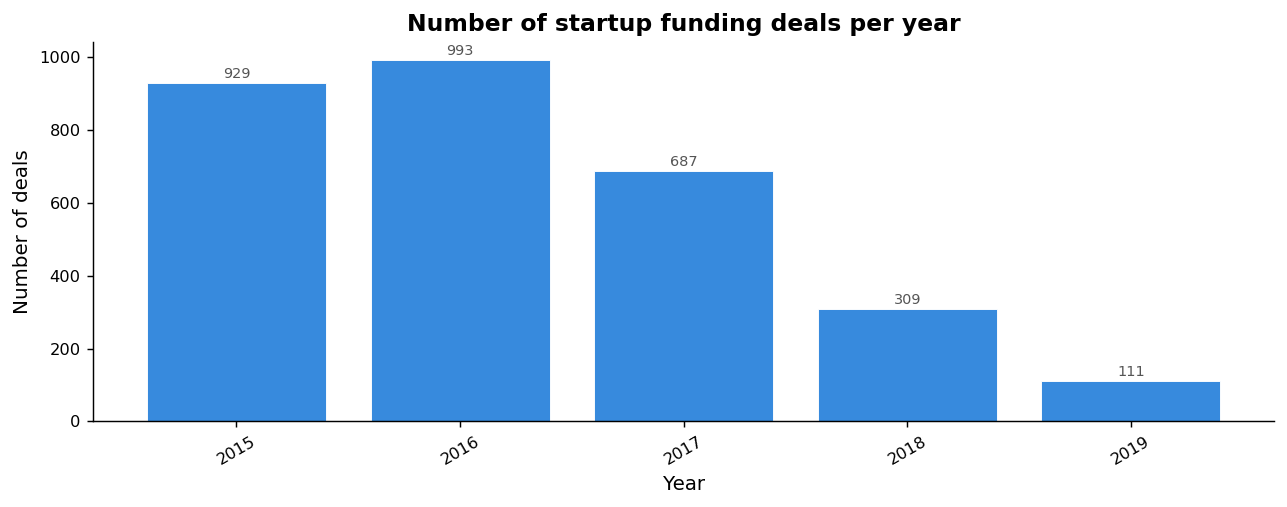

In [26]:
# ════════════════════════════════════════════════════════════
#  QUESTION 1: How has startup funding grown over the years?
# ════════════════════════════════════════════════════════════

# Count how many deals happened in each year
deals_per_year = (
    df.groupby("year")["startup"]
    .count()
    .reset_index()
    .rename(columns={"startup": "deal_count"})
)

# Only keep years with enough data (more than 10 deals)
deals_per_year = deals_per_year[deals_per_year["deal_count"] > 10]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    deals_per_year["year"],
    deals_per_year["deal_count"],
    color=BLUE, edgecolor="white", linewidth=0.5
)

# Add number label on top of each bar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=8, color="#555"
    )
ax.set_title("Number of startup funding deals per year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of deals")
ax.set_xticks(deals_per_year["year"])
ax.set_xticklabels(deals_per_year["year"].astype(int), rotation=30)
plt.tight_layout()
plt.savefig("../outputs/chart1_deals_per_year.png", bbox_inches="tight")
plt.show()

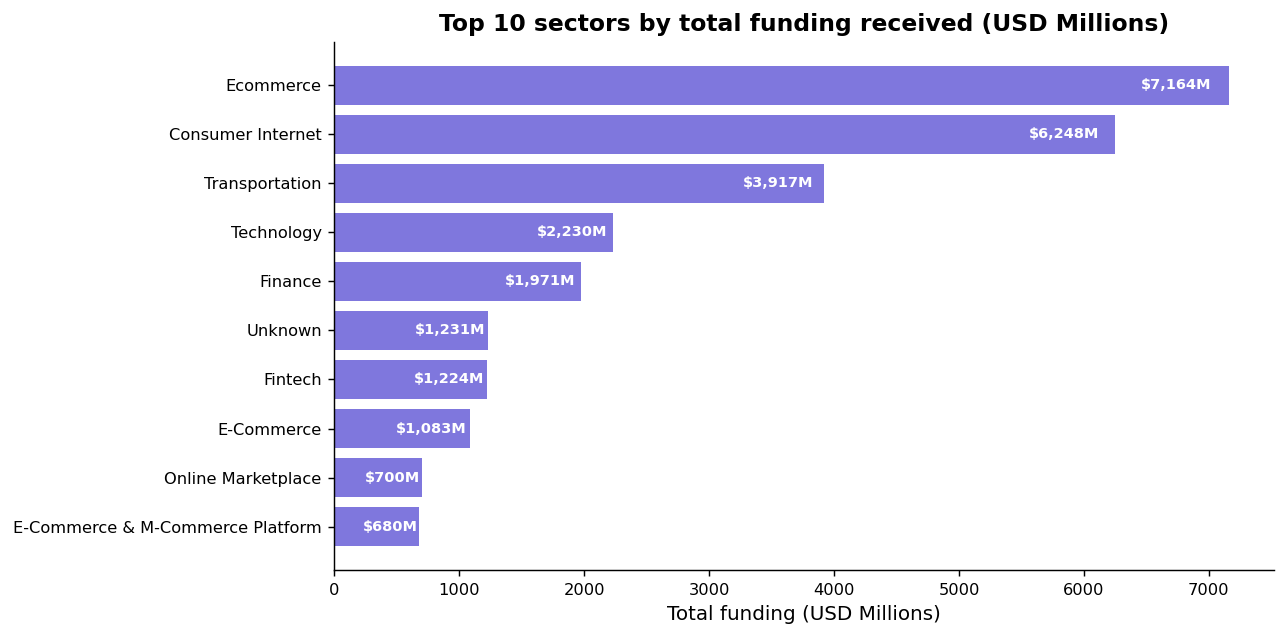

In [27]:
# ════════════════════════════════════════════════════════════
#  QUESTION 2: Which sectors get the most funding?
# ════════════════════════════════════════════════════════════

top_sectors = (
    df[df["amount_usd"].notna()]          # only rows with a known amount
    .groupby("industry")["amount_usd"]
    .sum()
    .sort_values(ascending=True)          # ascending so highest is at top
    .tail(10)                             # top 10 only
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_sectors.index, top_sectors.values / 1e6, color=PURPLE)

# Add value labels inside bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width * 0.98, bar.get_y() + bar.get_height() / 2,
        f"${width:,.0f}M",
        ha="right", va="center", fontsize=8, color="white", fontweight="bold"
    )
ax.set_title("Top 10 sectors by total funding received (USD Millions)")
ax.set_xlabel("Total funding (USD Millions)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../outputs/chart2_top_sectors.png", bbox_inches="tight")
plt.show()

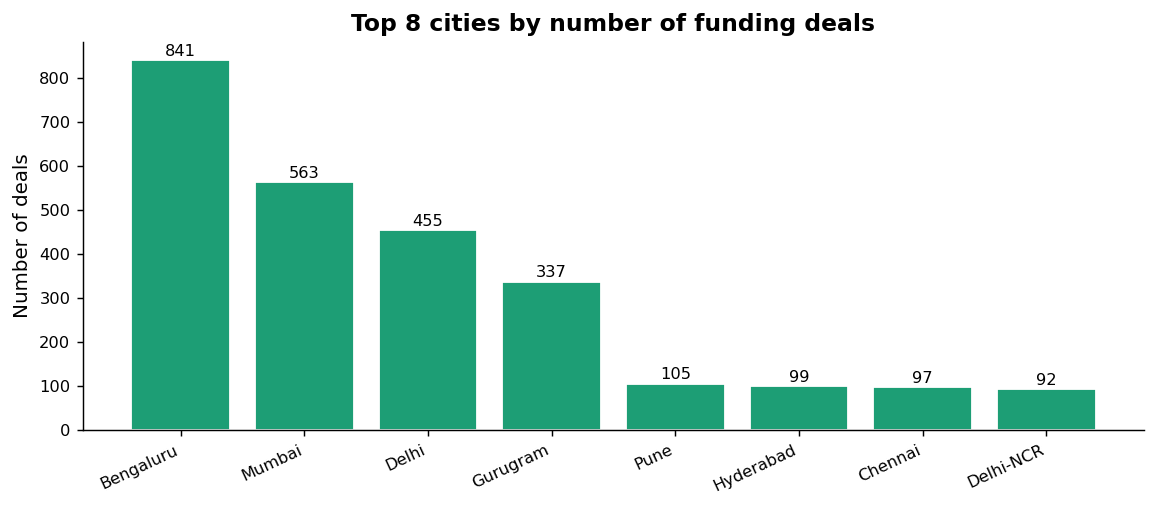

In [28]:
# ════════════════════════════════════════════════════════════
#  QUESTION 3: Which cities have the most startup activity?
# ════════════════════════════════════════════════════════════

top_cities = (
    df[df["city"] != "Unknown"]
    ["city"].value_counts()
    .head(8)
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(top_cities.index, top_cities.values, color=GREEN, edgecolor="white")
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=9
    )
ax.set_title("Top 8 cities by number of funding deals")
ax.set_ylabel("Number of deals")
ax.set_xlabel("")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("../outputs/chart3_top_cities.png", bbox_inches="tight")
plt.show()

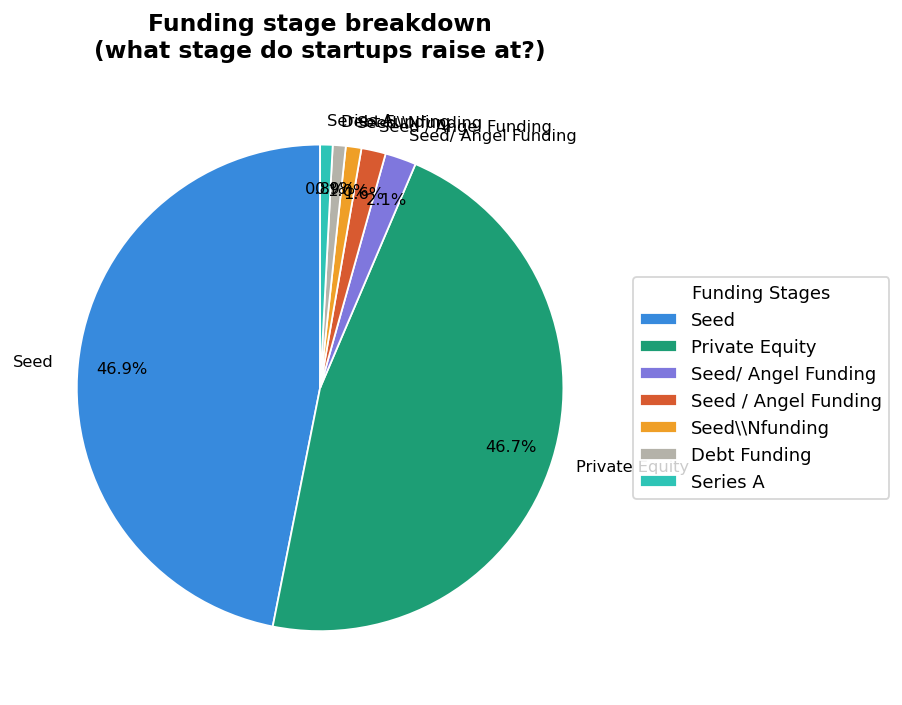

In [29]:
# ════════════════════════════════════════════════════════════
#  QUESTION 4: What stage do most startups raise money at?
# ════════════════════════════════════════════════════════════

stage_counts = (
    df[df["invest_type"] != "Unknown"]
    ["invest_type"].value_counts()
    .head(7)
)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    stage_counts.values,
    labels=stage_counts.index,
    autopct="%1.1f%%",
    colors=COLORS[:len(stage_counts)],
    startangle=90,
    pctdistance=0.82,
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)
# 2. Add a legend using the index from stage_counts
ax.legend(wedges, stage_counts.index, 
          title="Funding Stages", 
          loc="center left", 
          bbox_to_anchor=(1, 0, 0.5, 1))

for t in autotexts:
    t.set_fontsize(9)
ax.set_title("Funding stage breakdown\n(what stage do startups raise at?)", pad=15)
plt.tight_layout()
plt.savefig("../outputs/chart4_funding_stages.png", bbox_inches="tight")
plt.show()

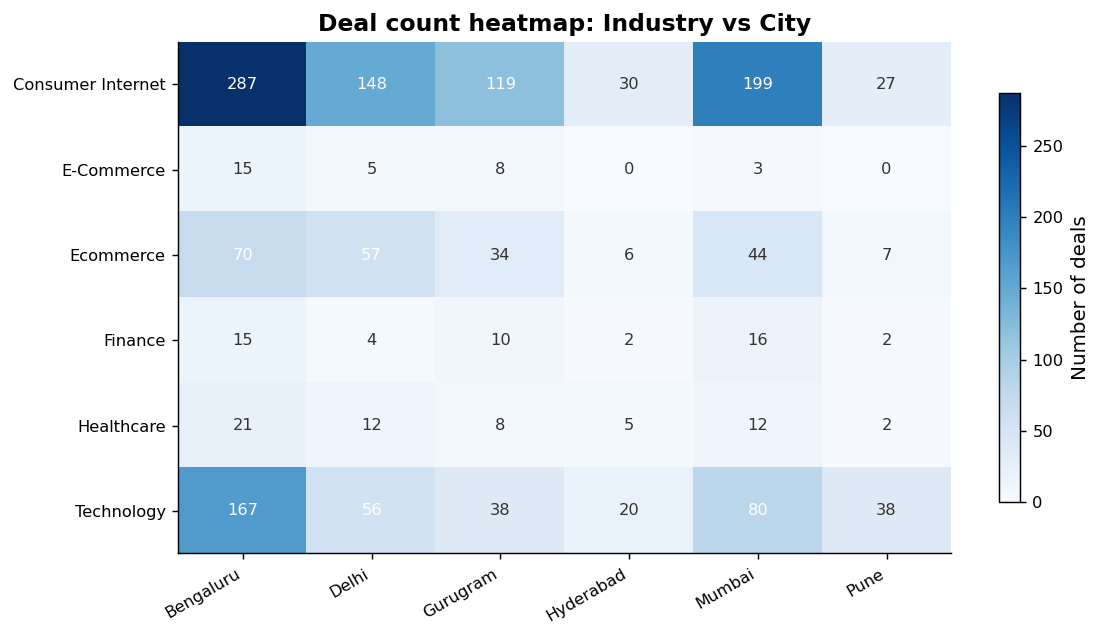

In [30]:
# ════════════════════════════════════════════════════════════
#  QUESTION 5: Which sector-city combo gets the most deals?
# ════════════════════════════════════════════════════════════

# Pick top 6 cities and top 6 industries for a clean heatmap
top6_cities = (
    df[df["city"] != "Unknown"]["city"]
    .value_counts().head(6).index.tolist()
)
top6_industries = (
    df[df["industry"] != "Unknown"]["industry"]
    .value_counts().head(6).index.tolist()
)

# Build a pivot table: rows = industry, columns = city, values = deal count
heatmap_data = (
    df[
        df["city"].isin(top6_cities) &
        df["industry"].isin(top6_industries)
    ]
    .groupby(["industry", "city"])["startup"]
    .count()
    .unstack(fill_value=0)
)

ig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(heatmap_data.values, cmap="Blues", aspect="auto")

# Add city names as x-axis labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=30, ha="right", fontsize=9)

# Add industry names as y-axis labels
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)

# Add numbers inside each cell
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=9, color="white" if val > 50 else "#333")

plt.colorbar(im, ax=ax, shrink=0.8, label="Number of deals")
ax.set_title("Deal count heatmap: Industry vs City")
plt.tight_layout()
plt.savefig("../outputs/chart5_sector_city_heatmap.png", bbox_inches="tight")
plt.show()

In [31]:
# ════════════════════════════════════════════════════════════
#  SUMMARY STATS — Print key numbers
# ════════════════════════════════════════════════════════════

total_funding = df["amount_usd"].sum()
avg_deal      = df["amount_usd"].mean()
top_city      = df[df["city"] != "Unknown"]["city"].value_counts().idxmax()
top_sector    = df[df["industry"] != "Unknown"]["industry"].value_counts().idxmax()
top_stage     = df[df["invest_type"] != "Unknown"]["invest_type"].value_counts().idxmax()
best_year     = deals_per_year.loc[deals_per_year["deal_count"].idxmax(), "year"]

In [32]:
total_funding

np.float64(38047507864.22)

In [33]:
avg_deal 

np.float64(18478634.222544927)

In [34]:
top_city

'Bengaluru'

In [35]:
top_sector 

'Consumer Internet'

In [36]:
top_stage 

'Seed'

In [37]:
best_year

np.float64(2016.0)

# step3 - Model building

In [38]:
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder
from sklearn.metrics          import (classification_report,confusion_matrix,accuracy_score)

In [39]:
# ════════════════════════════════════════════════════════════
#  STEP 1: Create the target variable
# ════════════════════════════════════════════════════════════
# We need to decide what "success" means.
# We define it as: did the startup raise MORE than the
# average funding amount?
#   1 = raised above median  → "funded well"
#   0 = raised below median  → "not funded well"
#
# We use MEDIAN (not average/mean) because a few huge deals
# like $500M would pull the mean up unrealistically.

df_model = df[df["amount_usd"].notna()].copy()  # only rows with known amount
median_amt = df_model["amount_usd"].median()

df_model["funded_well"] = (df_model["amount_usd"] > median_amt).astype(int)
class_counts = df_model["funded_well"].value_counts()


In [40]:
# ════════════════════════════════════════════════════════════
#  STEP 2: Select features and prepare them
# ════════════════════════════════════════════════════════════
# Features are the INPUT columns the model learns from.
# We choose: industry, city, invest_type, year, month
#
# IMPORTANT: ML models only understand NUMBERS.
# So we convert text columns (industry, city, invest_type)
# into numbers using LabelEncoder.
# Example: "Fintech" → 5,  "EdTech" → 2,  etc.

features = ["industry", "city", "invest_type", "year", "month"]
target   = "funded_well"

# Drop rows where any feature column is missing
df_model = df_model[features + [target]].dropna()
df_model = df_model[df_model["invest_type"] != "Unknown"]
df_model = df_model[df_model["city"]        != "Unknown"]
df_model = df_model[df_model["industry"]    != "Unknown"]

# Encode text columns into numbers
label_encoders = {}   # we save the encoders to use in simulator later

for col in ["industry", "city", "invest_type"]:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    print(f"  → Encoded '{col}': {len(le.classes_)} unique values")

# Save the encoding maps so simulator can decode predictions back to text
encoding_map = {}
for col, le in label_encoders.items():
    encoding_map[col] = dict(zip(range(len(le.classes_)), le.classes_))

X = df_model[features]
y = df_model[target]

print(f"\n  Final feature matrix shape: {X.shape}")

  → Encoded 'industry': 566 unique values
  → Encoded 'city': 81 unique values
  → Encoded 'invest_type': 39 unique values

  Final feature matrix shape: (1923, 5)


In [41]:
# ════════════════════════════════════════════════════════════
#  STEP 3: Split data into training and testing sets
# ════════════════════════════════════════════════════════════
# We train the model on 80% of data.
# We test it on the remaining 20% (data it has never seen).
# This tells us how well the model works on new startups.

print("\n  STEP 3: Splitting data (80% train / 20% test)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,     # 20% for testing
    random_state = 42,      # ensures same split every time you run
    stratify     = y        # keeps class balance in both splits
)

print(f"  → Training set : {len(X_train)} rows")
print(f"  → Testing set  : {len(X_test)} rows")


  STEP 3: Splitting data (80% train / 20% test)...
  → Training set : 1538 rows
  → Testing set  : 385 rows


In [42]:
# ════════════════════════════════════════════════════════════
#  STEP 4: Train the model
# ════════════════════════════════════════════════════════════
# Random Forest = many decision trees working together.
# Think of it like asking 100 different experts for their
# opinion and taking the majority vote.
#
# n_estimators = how many trees (100 is a good start)
# random_state = makes results reproducible

print("\n  STEP 4: Training Random Forest model...")
print("  (this may take 10–30 seconds...)")

model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    class_weight = "balanced"  # handles if one class has more rows
)
model.fit(X_train, y_train)

print("  ✓  Model trained!")


  STEP 4: Training Random Forest model...
  (this may take 10–30 seconds...)
  ✓  Model trained!



  STEP 5: Evaluating model performance...

  ✓  Model Accuracy: 84.7%

  Detailed report:
                     precision    recall  f1-score   support

Not Funded Well (0)       0.88      0.81      0.84       192
    Funded Well (1)       0.82      0.89      0.85       193

           accuracy                           0.85       385
          macro avg       0.85      0.85      0.85       385
       weighted avg       0.85      0.85      0.85       385



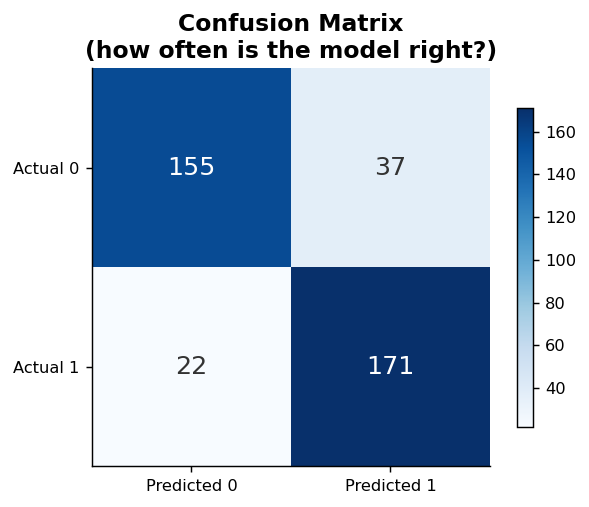

  ✓ Saved: chart6_confusion_matrix.png


In [43]:
# ════════════════════════════════════════════════════════════
#  STEP 5: Evaluate the model
# ════════════════════════════════════════════════════════════
# We test the model on data it never saw during training.
# Accuracy of 65–78% is good for this type of problem.

print("\n  STEP 5: Evaluating model performance...")

y_pred  = model.predict(X_test)
acc     = accuracy_score(y_test, y_pred)

print(f"\n  ✓  Model Accuracy: {acc:.1%}")
print(f"\n  Detailed report:")
print(classification_report(y_test, y_pred,
      target_names=["Not Funded Well (0)", "Funded Well (1)"]))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted 0", "Predicted 1"])
ax.set_yticklabels(["Actual 0",    "Actual 1"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                fontsize=14, color="white" if cm[i, j] > cm.max()/2 else "#333")
ax.set_title("Confusion Matrix\n(how often is the model right?)")
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.savefig("../outputs/chart6_confusion_matrix.png", bbox_inches="tight")
plt.show()
print("  ✓ Saved: chart6_confusion_matrix.png")


  STEP 6: Feature importance analysis...


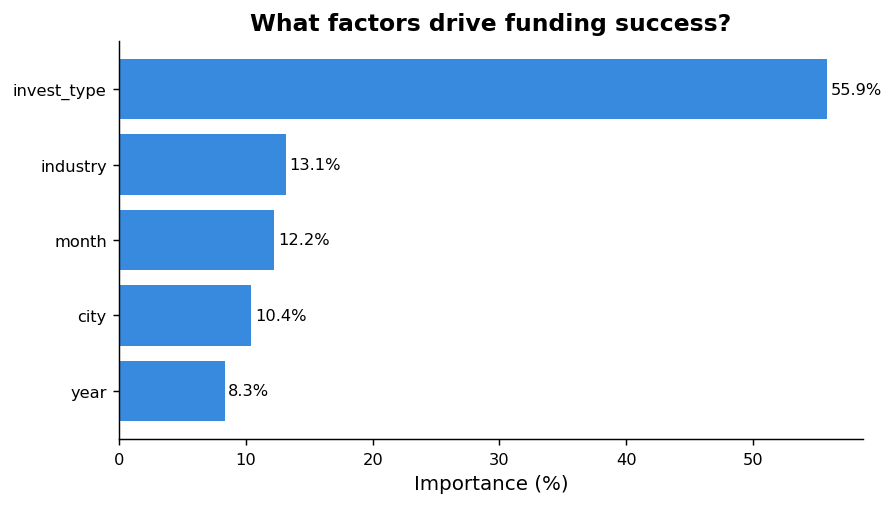

  Top features:
  → invest_type     : 55.9%
  → industry        : 13.1%
  → month           : 12.2%
  → city            : 10.4%
  → year            : 8.3%


In [44]:
# ════════════════════════════════════════════════════════════
#  STEP 6: Feature importance — what drives funding success?
# ════════════════════════════════════════════════════════════
# Feature importance tells us WHICH INPUT had the most
# influence on the model's decision.

print("\n  STEP 6: Feature importance analysis...")

importances = pd.Series(
    model.feature_importances_,
    index=features
).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(importances.index, importances.values * 100, color="#378ADD")
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%", va="center", fontsize=9)
ax.set_title("What factors drive funding success?")
ax.set_xlabel("Importance (%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/chart7_feature_importance.png", bbox_inches="tight")
plt.show()

print("  Top features:")
for feat, imp in importances.sort_values(ascending=False).items():
    print(f"  → {feat:15s} : {imp:.1%}")

In [45]:
# STEP 7: Export predictions for Power BI
print("\nSTEP 7: Exporting predictions...")

# Select required columns safely
cols = features + ["startup", "amount_usd"]
if "funded_well" in df.columns:
    cols.append("funded_well")

df_full = df[cols].copy()

# Clean data
df_full = df_full.dropna(subset=features)

#  Standardize text BEFORE filtering & encoding
for col in ["industry", "city", "invest_type"]:
    df[col] = df[col].astype(str).str.upper()
    
    unique_vals = list(df[col].unique())
    unique_vals.append("UNKNOWN")  
    
    le = LabelEncoder()
    le.fit(unique_vals)
    
    label_encoders[col] = le

# Remove unknowns
df_full = df_full[
    (df_full["industry"] != "UNKNOWN") &
    (df_full["city"] != "UNKNOWN") &
    (df_full["invest_type"] != "UNKNOWN")
]

# Save original values (for Power BI)
orig_vals = df_full[["industry", "city", "invest_type"]].copy()

for col in ["industry", "city", "invest_type"]:
    df_full[col] = df_full[col].apply(
        lambda x: x if x in label_encoders[col].classes_ else "UNKNOWN"
    )
    df_full[col] = label_encoders[col].transform(df_full[col])

# Predict
probs = model.predict_proba(df_full[features])[:, 1]
preds = model.predict(df_full[features])

# Create export dataframe
export_df = df_full.copy()
export_df[["industry", "city", "invest_type"]] = orig_vals
export_df["predicted_success"] = preds
export_df["confidence_score"] = probs.round(3)
export_df["outlook"] = pd.cut(
    probs, bins=[0, 0.4, 0.65, 1.0],
    labels=["Low", "Medium", "High"]
)

# Save file
export_df.to_csv("../outputs/predictions.csv", index=False)

print(f"✓ Saved predictions.csv ({len(export_df)} rows)")
print(export_df["outlook"].value_counts())



STEP 7: Exporting predictions...
✓ Saved predictions.csv (3036 rows)
outlook
Low       2171
Medium     690
High       175
Name: count, dtype: int64


In [46]:
# Save model + encoders
import pickle
pickle.dump(model, open("../outputs/model.pkl", "wb"))
pickle.dump(label_encoders, open("../outputs/label_encoders.pkl", "wb"))


In [47]:
# ── Load saved model and encoders ────────────────────────────
# In 03_model.py we trained the model and saved it as a file.
# Here we load it back so we don't have to retrain every time.

model_path    = "outputs/model.pkl"
encoders_path = "outputs/label_encoders.pkl"

if not os.path.exists(model_path):
    print("\n⚠  model.pkl not found. Please run 03_model.py first.")
    exit()

with open(model_path, "rb") as f:
    model = pickle.load(f)

with open(encoders_path, "rb") as f:
    label_encoders = pickle.load(f)

print("\n✓  Model and encoders loaded successfully")

# Get the list of known values for each category
# These are all the cities/industries/stages that exist in training data
known_industries = list(label_encoders["industry"].classes_)
known_cities     = list(label_encoders["city"].classes_)
known_stages     = list(label_encoders["invest_type"].classes_)

print(f"  Known industries : {len(known_industries)}")
print(f"  Known cities     : {len(known_cities)}")
print(f"  Known stages     : {len(known_stages)}")


# ════════════════════════════════════════════════════════════
#  PART A: Single startup predictor
# ════════════════════════════════════════════════════════════
# This function takes any startup's details and returns
# a funding success probability (0% to 100%).

def predict_startup(industry, city, invest_type, year, month):
    """
    Predict funding success for a single startup.

    Parameters:
    -----------
    industry    : str  → e.g. "Fintech", "Edtech", "Healthcare"
    city        : str  → e.g. "Bengaluru", "Mumbai", "Delhi"
    invest_type : str  → e.g. "Seed", "Series A", "Series B"
    year        : int  → e.g. 2024
    month       : int  → 1 to 12

    Returns:
    --------
    Prints the prediction result with recommendation.
    """

    print("\n" + "─" * 55)
    print("  STARTUP PREDICTION")
    print("─" * 55)
    print(f"  Industry    : {industry}")
    print(f"  City        : {city}")
    print(f"  Stage       : {invest_type}")
    print(f"  Year/Month  : {year} / {month}")

    # Check if the values entered exist in our training data
    # If not, find the closest match
    if industry not in known_industries:
        print(f"\n  ⚠  '{industry}' not in training data.")
        print(f"     Known industries: {known_industries[:8]}...")
        return

    if city not in known_cities:
        print(f"\n  ⚠  '{city}' not in training data.")
        print(f"     Known cities: {known_cities[:8]}...")
        return

    if invest_type not in known_stages:
        print(f"\n  ⚠  '{invest_type}' not in training data.")
        print(f"     Known stages: {known_stages}")
        return

    # Encode text values into numbers (same way we did in training)
    row = {
        "industry"   : label_encoders["industry"].transform([industry])[0],
        "city"       : label_encoders["city"].transform([city])[0],
        "invest_type": label_encoders["invest_type"].transform([invest_type])[0],
        "year"       : year,
        "month"      : month
    }

    # Create a one-row dataframe and predict
    X_new = pd.DataFrame([row])
    prob  = model.predict_proba(X_new)[0][1]  # probability of "funded_well = 1"

    # Label the result
    if prob > 0.65:
        outlook = "HIGH"
        icon    = "🟢"
    elif prob > 0.4:
        outlook = "MEDIUM"
        icon    = "🟡"
    else:
        outlook = "LOW"
        icon    = "🔴"

    print(f"\n  {icon} SUCCESS PROBABILITY : {prob:.1%}")
    print(f"     FUNDING OUTLOOK     : {outlook}")

    # Give a practical recommendation based on result
    print(f"\n  RECOMMENDATION:")
    if outlook == "HIGH":
        print("  → Strong profile. Focus on traction metrics and investor fit.")
        print("    Good timing + sector combo for fundraising.")
    elif outlook == "MEDIUM":
        print("  → Decent profile. Consider strengthening your pitch deck.")
        print("    Targeting Bengaluru or Mumbai could improve odds.")
    else:
        print("  → Weak profile for above-average funding.")
        print("    Consider: earlier stage (Seed/Angel), or pivot city to")
        print("    Bengaluru/Mumbai, or sector to Fintech/Consumer Internet.")

    print("─" * 55)
    return prob


# ════════════════════════════════════════════════════════════
#  PART B: Generate 500 what-if scenarios
# ════════════════════════════════════════════════════════════
# We randomly combine:
#   - different industries
#   - different cities
#   - different funding stages
#   - different years/months
# ...and score each one.
# This creates the "simulation" dataset for Power BI.

def run_simulation(n_scenarios=500, seed=42):
    """
    Generate n_scenarios random startup profiles and score each.
    Saves results to outputs/simulation_results.csv
    """
    print(f"\n  Generating {n_scenarios} what-if scenarios...")
    np.random.seed(seed)

    scenarios = []

    for i in range(n_scenarios):
        # Pick random values for each feature
        ind = np.random.choice(known_industries)
        cty = np.random.choice(known_cities)
        ivt = np.random.choice(known_stages)
        yr  = np.random.randint(2020, 2026)
        mo  = np.random.randint(1, 13)

        # Encode to numbers
        row = {
            "industry"   : label_encoders["industry"].transform([ind])[0],
            "city"       : label_encoders["city"].transform([cty])[0],
            "invest_type": label_encoders["invest_type"].transform([ivt])[0],
            "year"       : yr,
            "month"      : mo
        }

        # Predict success probability
        prob = model.predict_proba(pd.DataFrame([row]))[0][1]

        # Save scenario with original text + score
        scenarios.append({
            "scenario_id"   : i + 1,
            "industry"      : ind,
            "city"          : cty,
            "invest_type"   : ivt,
            "year"          : yr,
            "month"         : mo,
            "success_score" : round(prob, 4),
            "outlook"       : "High"   if prob > 0.65
                              else "Medium" if prob > 0.4
                              else "Low"
        })

    sim_df = pd.DataFrame(scenarios)

    # Save to CSV for Power BI
    sim_df.to_csv("outputs/simulation_results.csv", index=False)

    print(f"\n  ✓  Simulation complete!")
    print(f"     Total scenarios  : {len(sim_df)}")
    print(f"\n     Outlook breakdown:")
    print(sim_df["outlook"].value_counts().to_string())

    print(f"\n     Top 5 highest scoring scenarios:")
    top5 = (sim_df.sort_values("success_score", ascending=False)
            .head(5)[["industry","city","invest_type","year","success_score"]])
    print(top5.to_string(index=False))

    print(f"\n     Bottom 5 lowest scoring scenarios:")
    bot5 = (sim_df.sort_values("success_score")
            .head(5)[["industry","city","invest_type","year","success_score"]])
    print(bot5.to_string(index=False))

    return sim_df


# ════════════════════════════════════════════════════════════
#  RUN EVERYTHING
# ════════════════════════════════════════════════════════════

# --- Part A: Try some example predictions ---
print("\n  PART A — EXAMPLE PREDICTIONS")
predict_startup("Fintech",          "Bengaluru", "Series A", 2024, 6)
predict_startup("Edtech",           "Mumbai",    "Seed",     2023, 3)
predict_startup("Healthcare",       "Delhi",     "Series B", 2024, 9)
predict_startup("Consumer Internet","Bengaluru", "Series A", 2023, 1)

# --- Part B: Run simulation ---
print("\n  PART B — RUNNING SIMULATION")
sim_df = run_simulation(n_scenarios=500)

print("\n" + "=" * 55)
print("  ALL OUTPUTS READY FOR POWER BI")
print("=" * 55)
print("  Files in outputs/ folder:")
print("  → predictions.csv         (from 03_model.py)")
print("  → simulation_results.csv  (just generated)")
print("  → chart1 to chart7 PNGs   (from 02_eda.py)")
print("\n  Next step: Open Power BI Desktop")
print("  Import both CSV files and build your dashboard!")


✓  Model and encoders loaded successfully
  Known industries : 798
  Known cities     : 110
  Known stages     : 47

  PART A — EXAMPLE PREDICTIONS

───────────────────────────────────────────────────────
  STARTUP PREDICTION
───────────────────────────────────────────────────────
  Industry    : Fintech
  City        : Bengaluru
  Stage       : Series A
  Year/Month  : 2024 / 6

  ⚠  'Fintech' not in training data.
     Known industries: [np.str_('360-DEGREE VIEW CREATING PLATFORM'), np.str_('3D PRINTER MANUFACTURER'), np.str_('ACCOUNTING'), np.str_('ACTIVITY BASED SOCIAL NETWORK'), np.str_('ADVERTISING & MARKETING COMMUNITY NETWORKING PLATFORM'), np.str_('ADVERTISING, MARKETING'), np.str_('AEROSPACE'), np.str_('AFFORDABLE EDUCATION')]...

───────────────────────────────────────────────────────
  STARTUP PREDICTION
───────────────────────────────────────────────────────
  Industry    : Edtech
  City        : Mumbai
  Stage       : Seed
  Year/Month  : 2023 / 3

  ⚠  'Edtech' not in t

In [48]:
df

,date,startup,industry,subvertical,city,investors,invest_type,amount_usd,year,month
0,2020-01-09,BYJUâS,E-TECH,E-learning,BENGALURU,Tiger Global Management,PRIVATE EQUITY ROUND,200000000.0,2020.0,1.0
1,2020-01-13,Shuttl,TRANSPORTATION,App based shuttle service,GURUGRAM,Susquehanna Growth Equity,SERIES C,8048394.0,2020.0,1.0
2,2020-01-09,Mamaearth,E-COMMERCE,Retailer of baby and toddler products,BENGALURU,Sequoia Capital India,SERIES B,18358860.0,2020.0,1.0
3,2020-01-02,https://www.wealthbucket.in/,FINTECH,Online Investment,DELHI,Vinod Khatumal,PRE-SERIES A,3000000.0,2020.0,1.0
4,2020-01-02,Fashor,FASHION AND APPAREL,Embroiled Clothes For Women,MUMBAI,Sprout Venture Partners,SEED,1800000.0,2020.0,1.0
...,...,...,...,...,...,...,...,...,...,...
3039,2015-01-29,Printvenue,UNKNOWN,NaN,UNKNOWN,Asia Pacific Internet Group,PRIVATE EQUITY,4500000.0,2015.0,1.0
3040,2015-01-29,Graphene,UNKNOWN,NaN,UNKNOWN,KARSEMVEN Fund,PRIVATE EQUITY,825000.0,2015.0,1.0
3041,2015-01-30,Mad Street Den,UNKNOWN,NaN,UNKNOWN,"Exfinity Fund, GrowX Ventures.",PRIVATE EQUITY,1500000.0,2015.0,1.0
3042,2015-01-30,Simplotel,UNKNOWN,NaN,UNKNOWN,MakeMyTrip,PRIVATE EQUITY,NaN,2015.0,1.0
